## **Baseline proximity graph with retention tier projection**

### *Clinical Trial CTN-0051: Extended-Release Naltroxone vs. Buprenorphine for Opioid Treatment*

---

This notebook builds a **proximity graph** on the pre-trial baseline feature matrix as a precursor to full Mapper. The pipeline is:

1. Load `pre_trial.csv` and `target.csv`
2. Compute pairwise distances between patients
3. Build an ε-neighbourhood graph: connect patients $i$ and $j$ if $d(i,j) \leq \varepsilon$
4. Project (colour) nodes by `retention_tier`
5. Prune edges between non-consecutive tiers (keep tier 0–1, 1–2, 2–3, 3–4; remove 0–2, 0–3 etc.)
6. Lay out and display interactively with **Bokeh**

**Tunable parameters** (adjust in Section 2):
- `EPSILON` — neighbourhood radius in normalised feature space
- `METRIC` — distance metric (`'euclidean'`, `'cosine'`, `'manhattan'`)
- `MAX_TIER_GAP` — maximum allowed tier difference for an edge to survive pruning

## 0. Imports

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
import networkx as nx

from bokeh.plotting import figure, show, output_notebook
from bokeh.models import (
    ColumnDataSource, HoverTool, ColorBar, LinearColorMapper,
    Slider, CustomJS, MultiLine, Circle, Select,
    Div, Row, Column, Legend, LegendItem
)
from bokeh.transform import factor_cmap
from bokeh.palettes import RdYlGn5, Spectral5
from bokeh.io import push_notebook

output_notebook()
print("Imports OK")

Loading BokehJS ...

Imports OK


## 1. Load data

In [3]:
# ── Load pre-trial features, target, and week-8 landmark features ─────────────
pre_trial = pd.read_csv("../data/clean-data/pre-trial.csv")
target    = pd.read_csv("../data/clean-data/retention_tier.csv")
w8        = pd.read_csv("../data/clean-data/features_w8.csv")

# Join on PATID
df = (
    pre_trial
    .merge(target[['PATID', 'retention_tier']], on='PATID', how='inner')
    .merge(w8, on='PATID', how='inner')
)

print(f"Patients        : {len(df)}")
print(f"Features        : {pre_trial.shape[1] - 1}")
print(f"\nRetention tier distribution:")
print(df['retention_tier'].value_counts().sort_index().to_string())
print(f"\nWeek-8 landmark features:")
print(f"  had_relapse_by_w8      : {df['had_relapse_by_w8'].value_counts().sort_index().to_dict()}")
print(f"  engagement_onset_w8    : {df['engagement_onset_w8'].value_counts().sort_index().to_dict()}  (0=on_time 1=slightly_delayed 2=late 3=not_yet)")
print(f"  attendance_density_w8  : mean={df['attendance_density_w8'].mean():.3f}")

Patients        : 554
Features        : 84

Retention tier distribution:
retention_tier
1    164
2    108
3     61
4    221

Week-8 landmark features:
  had_relapse_by_w8      : {0: 371, 1: 183}
  engagement_onset_w8    : {0: 436, 1: 100, 2: 17, 3: 1}  (0=on_time 1=slightly_delayed 2=late 3=not_yet)
  attendance_density_w8  : mean=0.736


In [93]:
# ── Define feature matrix ─────────────────────────────────────────────────────
exclude = [
    'PATID', 'retention_tier', 'retention_tier_label',
    'last_opioid_date',          # date — not analytic
    'last_substance_label',      # string duplicate
    'last_route_label',          # string duplicate
    'discharge_facility_label',  # string duplicate
    # Redundant date cols (both derivable from detox_los)
    'detox_admission_day', 'detox_discharge_day',
    # Zero-variance (constant 1.0 for all patients — opioid trial)
    'opi_past_12_months',
    # Near-constant DSM opioid criterion items
    'opi_withdrawal', 'opi_tolerance', 'opi_strong_craving',
    'opi_social_problems', 'opi_continued_use_despite_problems',
    'opi_larger_longer_dose', 'opi_cut_back_unsuccess',
    'opi_time_spent', 'opi_activities_reduced',
    'opi_recurrent_obligat_fail', 'opi_hazardous_use',
    # Socioeconomic variables
    # 'education_years',
    # 'occupation_category',
    # 'has_drivers_licence',
    # 'has_automobile',
    # 'days_paid_employment_30d',
    # 'days_any_employment_30d',
    # 'income_employment_30d',
    # 'income_unemployment_30d',
    # 'income_welfare_30d',
    # 'income_illegal_30d',
    # 'n_dependants',
    'had_relapse_by_w8', 'engagement_onset_w8', 'attendance_density_w8' 
    
]
feat_cols = [
    c for c in df.columns
    if c not in exclude
    and df[c].dtype != object
    and not c.startswith('sow_')         # SOW withdrawal scale items (all variants)
    and not c.startswith('dsm_')         # DSM substance score composites
    and not c.endswith('_baseline_x')    # _x/_y SOW merge artifacts
    and not c.endswith('_baseline_y')
]

X_raw = df[feat_cols].values
print(f"Feature matrix shape: {X_raw.shape}")
print(f"Excluded columns    : {df.shape[1] - len(feat_cols)} / {df.shape[1]}")
print(f"Missing values      : {np.isnan(X_raw).sum()}")
print(f"\nFeatures kept:")
for c in feat_cols:
    print(f"  {c}")

Feature matrix shape: (554, 15)
Excluded columns    : 74 / 89
Missing values      : 0

Features kept:
  last_substance_code
  last_route_code
  discharge_facility_code
  detox_los
  education_years
  occupation_category
  has_drivers_licence
  has_automobile
  days_paid_employment_30d
  days_any_employment_30d
  income_employment_30d
  income_unemployment_30d
  income_welfare_30d
  income_illegal_30d
  n_dependants


## 2. Parameters — tune here

In [84]:
# ══════════════════════════════════════════════════════════════════════════════
# TUNABLE PARAMETERS
# ══════════════════════════════════════════════════════════════════════════════

EPSILON      = 0.3   # neighbourhood radius in standardised feature space
                      # set near the 50th percentile of the distance distribution

METRIC       = 'cosine'
MINKOWSKI_P  = 3

MAX_TIER_GAP = 1

LAYOUT       = 'spring'

# Filter function for the Mapper cover: attendance_density_w8 ∈ [0, 1]
# Values are discrete multiples of 1/8: 0, 0.125, 0.25, ..., 1.0
# BIN_EDGES / BIN_LABELS used for the diagnostic distribution plot only
BIN_EDGES    = [0, 0.25, 0.50, 0.75, 1.01]
BIN_LABELS   = ['0–25%', '25–50%', '50–75%', '75–100%']
MAX_BIN_GAP  = 1

print(f"Attendance density (w8) distribution:")
print(df['attendance_density_w8'].describe().round(3).to_string())
print(f"\nPatients per attendance bin:")
bins = pd.cut(df['attendance_density_w8'], bins=BIN_EDGES, labels=BIN_LABELS,
              right=False, include_lowest=True)
print(bins.value_counts().sort_index().to_string())

metric_str = f"{METRIC}(p={MINKOWSKI_P})" if METRIC == 'minkowski' else METRIC
print(f"\nε = {EPSILON}  |  metric = {metric_str}  |  max tier gap = {MAX_TIER_GAP}  |  layout = {LAYOUT}")

Attendance density (w8) distribution:
count    554.000
mean       0.736
std        0.311
min        0.000
25%        0.400
50%        0.800
75%        1.000
max        1.000

Patients per attendance bin:
attendance_density_w8
0–25%       94
25–50%      49
50–75%      69
75–100%    342

ε = 0.3  |  metric = cosine  |  max tier gap = 1  |  layout = spring


In [85]:
# ── Define open cover intervals ───────────────────────────────────────────────
# Filter function: attendance_density_w8 ∈ {0, 1/8, 2/8, ..., 8/8} (9 discrete values).
# 5 wide bins with step=0.125, width≈0.5 → ~75% overlap between adjacent sets.
# Every value except 0.0 and 1.0 falls in 2–4 sets; bridges most attendance groups.
# hi values offset by +0.001 to avoid excluding exact discrete boundary values (strict <).
COVER = [
    (0.000, 0.501),  # bin 0: 0%–50%   — values 0, 1/8, 2/8, 3/8, 4/8
    (0.125, 0.626),  # bin 1: 12%–62%  — values 1/8, 2/8, 3/8, 4/8, 5/8
    (0.250, 0.751),  # bin 2: 25%–75%  — values 2/8, 3/8, 4/8, 5/8, 6/8
    (0.375, 0.876),  # bin 3: 37%–87%  — values 3/8, 4/8, 5/8, 6/8, 7/8
    (0.500, 1.001),  # bin 4: 50%–100% — values 4/8, 5/8, 6/8, 7/8, 8/8
]
COVER_LABELS = [f'[{lo:.3f}, {hi:.3f})' for lo, hi in COVER]

# ── Assign cover memberships ──────────────────────────────────────────────────
filt = df['attendance_density_w8'].values

def get_memberships(val, cover):
    if np.isnan(val):
        return []
    return [i for i, (lo, hi) in enumerate(cover) if lo <= val < hi]

memberships = [get_memberships(v, COVER) for v in filt]

# Report
print("Cover membership distribution:")
for i, (lo, hi) in enumerate(COVER):
    n = sum(1 for m in memberships if i in m)
    print(f"  Set {i}  {COVER_LABELS[i]}: {n:3d} patients")

print(f"\nPatients by number of cover sets:")
for n_sets in [0, 1, 2, 3, 4, 5]:
    count = sum(1 for m in memberships if len(m) == n_sets)
    if count > 0 or n_sets <= 1:
        tag = "  ← disconnected!" if n_sets == 0 else ""
        print(f"  In exactly {n_sets} set(s): {count}{tag}")

print(f"\nDiscrete attendance values and their set memberships:")
for v in [0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0]:
    sets = get_memberships(v, COVER)
    n = sum(1 for x in filt if x == v)
    print(f"  {v:.3f}  ({n:3d} patients)  →  sets {sets}")

Cover membership distribution:
  Set 0  [0.000, 0.501): 143 patients
  Set 1  [0.125, 0.626): 211 patients
  Set 2  [0.250, 0.751): 118 patients
  Set 3  [0.375, 0.876): 187 patients
  Set 4  [0.500, 1.001): 411 patients

Patients by number of cover sets:
  In exactly 0 set(s): 0  ← disconnected!
  In exactly 1 set(s): 274
  In exactly 2 set(s): 162
  In exactly 4 set(s): 118

Discrete attendance values and their set memberships:
  0.000  (  1 patients)  →  sets [0]
  0.125  (  0 patients)  →  sets [0, 1]
  0.250  (  0 patients)  →  sets [0, 1, 2]
  0.375  (  0 patients)  →  sets [0, 1, 2, 3]
  0.500  (  0 patients)  →  sets [0, 1, 2, 3, 4]
  0.625  (  0 patients)  →  sets [1, 2, 3, 4]
  0.750  (  0 patients)  →  sets [2, 3, 4]
  0.875  (  0 patients)  →  sets [3, 4]
  1.000  (273 patients)  →  sets [4]


## 3. Preprocess and compute pairwise distances

In [86]:
# ── Standardise features ──────────────────────────────────────────────────────
scaler = StandardScaler()
X      = scaler.fit_transform(X_raw)
# X = X_raw  # no standardisation

# ── Pairwise distances ────────────────────────────────────────────────────────
metric_str = f"{METRIC}(p={MINKOWSKI_P})" if METRIC == 'minkowski' else METRIC
dist_kwargs = {"p": MINKOWSKI_P} if METRIC == 'minkowski' else {}

print(f"Computing {metric_str} pairwise distances for {len(df)} patients...")
D = pairwise_distances(X, metric=METRIC, **dist_kwargs)
print(f"Distance matrix shape : {D.shape}")
print(f"Distance range        : [{D.min():.3f}, {D.max():.3f}]")
print(f"\nDistance percentiles:")
for p in [10, 25, 50, 75, 90]:
    print(f"  {p:3d}th percentile : {np.percentile(D[D>0], p):.3f}")
print(f"\nWith ε = {EPSILON}:")
n_edges_raw = ((D <= EPSILON) & (D > 0)).sum() // 2
print(f"  Edges before tier pruning : {n_edges_raw}")
print(f"  Edge density              : {n_edges_raw / (len(df)*(len(df)-1)/2) * 100:.1f}%")

Computing cosine pairwise distances for 554 patients...
Distance matrix shape : (554, 554)
Distance range        : [0.000, 1.871]

Distance percentiles:
   10th percentile : 0.602
   25th percentile : 0.806
   50th percentile : 1.020
   75th percentile : 1.207
   90th percentile : 1.362

With ε = 0.3:
  Edges before tier pruning : 1824
  Edge density              : 1.2%


## 4. Build ε-neighbourhood graph

In [87]:
# ── Build graph ───────────────────────────────────────────────────────────────
tiers = df['retention_tier'].values

G = nx.Graph()

# Add nodes with attributes
tier_label_map = {
    0: 'Never engaged',
    1: 'Early dropout',
    2: 'Mid dropout',
    3: 'Late dropout',
    4: 'Completed',
}
for i in range(len(df)):
    G.add_node(
        i,
        patid       = int(df['PATID'].iloc[i]),
        tier        = int(tiers[i]) if not np.isnan(tiers[i]) else -1,
        tier_label  = tier_label_map.get(int(tiers[i]) if not np.isnan(tiers[i]) else -1, 'Unknown'),
    )

# Add edges: ε-neighbourhood + tier gap filter
edges_added   = 0
edges_pruned  = 0

for i in range(len(df)):
    for j in range(i + 1, len(df)):
        if D[i, j] <= EPSILON:
            tier_gap = abs(int(tiers[i]) - int(tiers[j])) \
                       if not (np.isnan(tiers[i]) or np.isnan(tiers[j])) else 99
            if tier_gap <= MAX_TIER_GAP:
                G.add_edge(i, j, weight=float(D[i, j]),
                           tier_gap=tier_gap)
                edges_added += 1
            else:
                edges_pruned += 1

print(f"Graph summary:")
print(f"  Nodes            : {G.number_of_nodes()}")
print(f"  Edges (kept)     : {G.number_of_edges()}   ({edges_added})")
print(f"  Edges (pruned)   : {edges_pruned}  (tier gap > {MAX_TIER_GAP})")
print(f"  Connected comps  : {nx.number_connected_components(G)}")
print(f"  Isolated nodes   : {sum(1 for n in G.nodes if G.degree(n)==0)}")

# Degree distribution by tier
print(f"\nMean degree by tier:")
for tier in sorted(tier_label_map.keys()):
    nodes_t = [n for n in G.nodes if G.nodes[n]['tier'] == tier]
    if nodes_t:
        mean_deg = np.mean([G.degree(n) for n in nodes_t])
        print(f"  Tier {tier} ({tier_label_map[tier]:<20s}): "
              f"{len(nodes_t):3d} nodes, mean degree = {mean_deg:.1f}")

Graph summary:
  Nodes            : 554
  Edges (kept)     : 1477   (1477)
  Edges (pruned)   : 347  (tier gap > 1)
  Connected comps  : 52
  Isolated nodes   : 43

Mean degree by tier:
  Tier 1 (Early dropout       ): 164 nodes, mean degree = 6.0
  Tier 2 (Mid dropout         ): 108 nodes, mean degree = 2.6
  Tier 3 (Late dropout        ):  61 nodes, mean degree = 7.8
  Tier 4 (Completed           ): 221 nodes, mean degree = 5.5


In [88]:
# ── Assign bin index to each patient ─────────────────────────────────────────
bin_indices = pd.cut(
    df['detox_los'],
    bins=BIN_EDGES,
    labels=False,        # integer 0,1,2,3
    right=False,
    include_lowest=True,
).values.astype(float)   # NaN for missing detox_los

bin_label_arr = pd.cut(
    df['detox_los'],
    bins=BIN_EDGES,
    labels=BIN_LABELS,
    right=False,
    include_lowest=True,
).astype(str).values

# Colour palette for bins (blue gradient: short stay → long stay)
bin_colors = {
    0: '#d62728',   # 0–3 days   — red (very short, likely induction failure)
    1: '#ff7f0e',   # 3–7 days   — orange
    2: '#2E5FAC',   # 7–14 days  — blue
    3: '#2ca02c',   # 14+ days   — green (extended stay)
    -1: '#aaaaaa',  # missing
}

# ── Build graph ───────────────────────────────────────────────────────────────
G = nx.Graph()

for i in range(len(df)):
    bin_i = int(bin_indices[i]) if not np.isnan(bin_indices[i]) else -1
    G.add_node(
        i,
        patid      = int(df['PATID'].iloc[i]),
        bin_idx    = bin_i,
        bin_label  = bin_label_arr[i],
        tier       = int(tiers[i]) if not np.isnan(tiers[i]) else -1,
        tier_label = tier_label_map.get(
                         int(tiers[i]) if not np.isnan(tiers[i]) else -1,
                         'Unknown'),
    )

edges_added  = 0
edges_pruned = 0

for i in range(len(df)):
    for j in range(i + 1, len(df)):
        if D[i, j] <= EPSILON:
            bi = int(bin_indices[i]) if not np.isnan(bin_indices[i]) else -1
            bj = int(bin_indices[j]) if not np.isnan(bin_indices[j]) else -1
            bin_gap = abs(bi - bj) if (bi >= 0 and bj >= 0) else 99
            if bin_gap <= MAX_BIN_GAP:
                G.add_edge(i, j, weight=float(D[i, j]), bin_gap=bin_gap)
                edges_added += 1
            else:
                edges_pruned += 1

print(f"Nodes          : {G.number_of_nodes()}")
print(f"Edges kept     : {edges_added}")
print(f"Edges pruned   : {edges_pruned}  (bin gap > {MAX_BIN_GAP})")
print(f"Components     : {nx.number_connected_components(G)}")

Nodes          : 554
Edges kept     : 0
Edges pruned   : 1824  (bin gap > 1)
Components     : 554


In [89]:
# ── Build graph with cover-based edge pruning ─────────────────────────────────
# Edge rule: two patients are connected if:
#   1. d(i,j) <= EPSILON  (proximity)
#   2. they share at least one open cover set  (Mapper condition)

G = nx.Graph()

def primary_set(m):
    return m[0] if m else -1

onset_label_map = {0: 'on_time', 1: 'slightly_delayed', 2: 'late', 3: 'not_yet_engaged'}

cover_colors = {
    -1: '#aaaaaa',
     0: '#d62728',
     1: '#ff7f0e',
     2: '#2E5FAC',
     3: '#2ca02c',
}

for i in range(len(df)):
    onset_i = int(df['engagement_onset_w8'].iloc[i])
    G.add_node(
        i,
        patid          = int(df['PATID'].iloc[i]),
        memberships    = memberships[i],
        primary_set    = primary_set(memberships[i]),
        in_overlap     = len(memberships[i]) > 1,
        tier           = int(tiers[i]) if not np.isnan(tiers[i]) else -1,
        tier_label     = tier_label_map.get(
                             int(tiers[i]) if not np.isnan(tiers[i]) else -1,
                             'Unknown'),
        had_relapse_w8 = int(df['had_relapse_by_w8'].iloc[i]),
        onset_w8       = onset_i,
        onset_w8_label = onset_label_map.get(onset_i, 'unknown'),
        attendance_w8  = float(df['attendance_density_w8'].iloc[i]),
    )

edges_added  = 0
edges_pruned = 0
edges_no_set = 0

for i in range(len(df)):
    for j in range(i + 1, len(df)):
        if D[i, j] <= EPSILON:
            mi = set(memberships[i])
            mj = set(memberships[j])
            if mi and mj and mi & mj:
                G.add_edge(i, j,
                           weight=float(D[i, j]),
                           shared_sets=list(mi & mj))
                edges_added += 1
            elif not mi or not mj:
                edges_no_set += 1
            else:
                edges_pruned += 1

print(f"Nodes             : {G.number_of_nodes()}")
print(f"Edges kept        : {edges_added}   (share ≥1 cover set)")
print(f"Edges pruned      : {edges_pruned}  (disjoint cover sets)")
print(f"Edges skipped     : {edges_no_set}  (missing LOS)")
print(f"Components        : {nx.number_connected_components(G)}")
print(f"\nOverlap nodes (in 2+ sets): "
      f"{sum(1 for n in G.nodes if G.nodes[n]['in_overlap'])}")

Nodes             : 554
Edges kept        : 1795   (share ≥1 cover set)
Edges pruned      : 29  (disjoint cover sets)
Edges skipped     : 0  (missing LOS)
Components        : 32

Overlap nodes (in 2+ sets): 280


## 5. Layout

In [90]:
# ── Compute node positions ────────────────────────────────────────────────────
print(f"Computing layout: {LAYOUT}...")

if LAYOUT == 'spring':
    # Spring layout weighted by distance (closer patients → stronger attraction)
    # Use inverse distance as edge weight so similar patients attract more
    G_weighted = G.copy()
    for u, v, data in G_weighted.edges(data=True):
        data['spring_weight'] = 1.0 / (data['weight'] + 1e-6)
    pos = nx.spring_layout(
        G_weighted, weight='spring_weight',
        k=5.0, iterations=50, seed=42
    )

elif LAYOUT == 'spectral':
    pos = nx.spectral_layout(G)

elif LAYOUT == 'pca':
    # Project onto first 2 PCA components of the feature matrix
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X)
    pos = {i: (coords[i, 0], coords[i, 1]) for i in range(len(df))}
    print(f"  PCA variance explained: "
          f"{pca.explained_variance_ratio_[0]*100:.1f}% + "
          f"{pca.explained_variance_ratio_[1]*100:.1f}%")

# Attach position to nodes
for node, (x, y) in pos.items():
    G.nodes[node]['x'] = float(x)
    G.nodes[node]['y'] = float(y)

print(f"Layout computed for {len(pos)} nodes.")

Computing layout: spring...


Layout computed for 554 nodes.


## 6. Interactive Bokeh visualisation

In [91]:
# ── Build Bokeh data sources ───────────────────────────────────────────────────

tier_colors = {
    -1: '#aaaaaa',
     0: '#d62728',
     1: '#ff7f0e',
     2: '#ffbb78',
     3: '#98df8a',
     4: '#2ca02c',
}

# ── Node source ───────────────────────────────────────────────────────────────
node_x         = [G.nodes[n]['x']             for n in G.nodes]
node_y         = [G.nodes[n]['y']             for n in G.nodes]
node_tier      = [G.nodes[n]['tier']          for n in G.nodes]
node_patid     = [G.nodes[n]['patid']         for n in G.nodes]
node_degree    = [G.degree(n)                 for n in G.nodes]
node_color     = [tier_colors[t]              for t in node_tier]
node_relapse   = [G.nodes[n]['had_relapse_w8']  for n in G.nodes]
node_onset     = [G.nodes[n]['onset_w8_label']  for n in G.nodes]
node_attend    = [G.nodes[n]['attendance_w8']   for n in G.nodes]

node_detox_los = [float(df['detox_los'].iloc[n])
                  if 'detox_los' in df.columns else float('nan')
                  for n in G.nodes]
node_substance = [str(df['last_substance_label'].iloc[n])
                  if 'last_substance_label' in df.columns else ''
                  for n in G.nodes]
node_opioid_score = [float(df['dsm_opioid_score'].iloc[n])
                     if 'dsm_opioid_score' in df.columns else float('nan')
                     for n in G.nodes]

node_source = ColumnDataSource(dict(
    x             = node_x,
    y             = node_y,
    tier          = [str(t) for t in node_tier],
    patid         = node_patid,
    degree        = node_degree,
    color         = node_color,
    detox_los     = node_detox_los,
    substance     = node_substance,
    opioid_score  = node_opioid_score,
    relapse_w8    = [str(r) for r in node_relapse],
    onset_w8      = node_onset,
    attendance_w8 = node_attend,
))

# ── Edge source ───────────────────────────────────────────────────────────────
edge_xs, edge_ys, edge_gap, edge_weight = [], [], [], []
edge_los_u, edge_los_v = [], []
for u, v, data in G.edges(data=True):
    edge_xs.append([G.nodes[u]['x'], G.nodes[v]['x']])
    edge_ys.append([G.nodes[u]['y'], G.nodes[v]['y']])
    edge_gap.append(len(data['shared_sets']) - 1)
    edge_weight.append(data['weight'])
    edge_los_u.append(float(df['detox_los'].iloc[u]))
    edge_los_v.append(float(df['detox_los'].iloc[v]))

edge_alpha = [0.6 if g == 0 else 0.25 for g in edge_gap]
edge_color = ['#555555' if g == 0 else '#aaaaaa' for g in edge_gap]

edge_source = ColumnDataSource(dict(
    xs     = edge_xs,
    ys     = edge_ys,
    gap    = edge_gap,
    weight = edge_weight,
    alpha  = edge_alpha,
    color  = edge_color,
    los_u  = edge_los_u,
    los_v  = edge_los_v,
))

print(f"Node source: {len(node_x)} nodes")
print(f"Edge source: {len(edge_xs)} edges")

Node source: 554 nodes
Edge source: 1795 edges


In [92]:
# ── Build Bokeh figure ────────────────────────────────────────────────────────
TOOLS = "pan,wheel_zoom,box_zoom,reset,save"

p = figure(
    title=(
        f"Baseline proximity graph  |  ε={EPSILON}  |  metric={METRIC}  |  "
        f"layout={LAYOUT}\n"
        f"{G.number_of_nodes()} patients · {G.number_of_edges()} edges  "
        f"({nx.number_connected_components(G)} connected components)"
    ),
    tools=TOOLS,
    width=900, height=700,
    x_axis_label='', y_axis_label='',
    background_fill_color='#FAFAFA',
)
p.title.text_font_size  = '11pt'
p.title.text_font_style = 'normal'
p.axis.visible          = False
p.grid.visible          = False
p.outline_line_color    = '#DDDDDD'

# ── Draw edges ────────────────────────────────────────────────────────────────
edges_renderer = p.multi_line(
    xs='xs', ys='ys',
    line_color='color',
    line_alpha='alpha',
    line_width=0.6,
    source=edge_source,
)

# ── Draw nodes ────────────────────────────────────────────────────────────────
node_source.data['size'] = [6] * len(node_x)

nodes_renderer = p.scatter(
    x='x', y='y',
    size='size',
    fill_color='color',
    fill_alpha=0.85,
    line_color='white',
    line_width=0.8,
    source=node_source,
)

# ── Hover tooltip ─────────────────────────────────────────────────────────────
node_hover = HoverTool(
    renderers=[nodes_renderer],
    tooltips=[
        ("PATID",              "@patid"),
        ("Tier",               "@tier"),
        ("Degree",             "@degree connections"),
        ("Detox LOS",          "@detox_los{0.0} days"),
        ("Last substance",     "@substance"),
        ("Opioid score",       "@opioid_score{0}"),
        ("─── Week-8 features ───", ""),
        ("Relapse by wk8",     "@relapse_w8"),
        ("Engagement onset",   "@onset_w8"),
        ("Attendance density", "@attendance_w8{0.000}"),
    ]
)
p.add_tools(node_hover)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_items = []
for tier_val, label in tier_label_map.items():
    n_tier = sum(1 for t in node_tier if t == tier_val)
    if n_tier == 0:
        continue
    dummy = p.scatter(
        x=[float('nan')], y=[float('nan')],
        size=10,
        fill_color=tier_colors[tier_val],
        line_color='white',
        line_width=0.8,
        fill_alpha=0.85,
    )
    legend_items.append(LegendItem(
        label=f"Tier {tier_val}: {label} (n={n_tier})",
        renderers=[dummy]
    ))

legend = Legend(
    items=legend_items,
    location='top_right',
    background_fill_alpha=0.9,
    border_line_color='#CCCCCC',
    label_text_font_size='9pt',
    glyph_width=12,
    glyph_height=12,
    spacing=4,
)
p.add_layout(legend, 'right')

show(p)

## 7. Graph statistics by tier

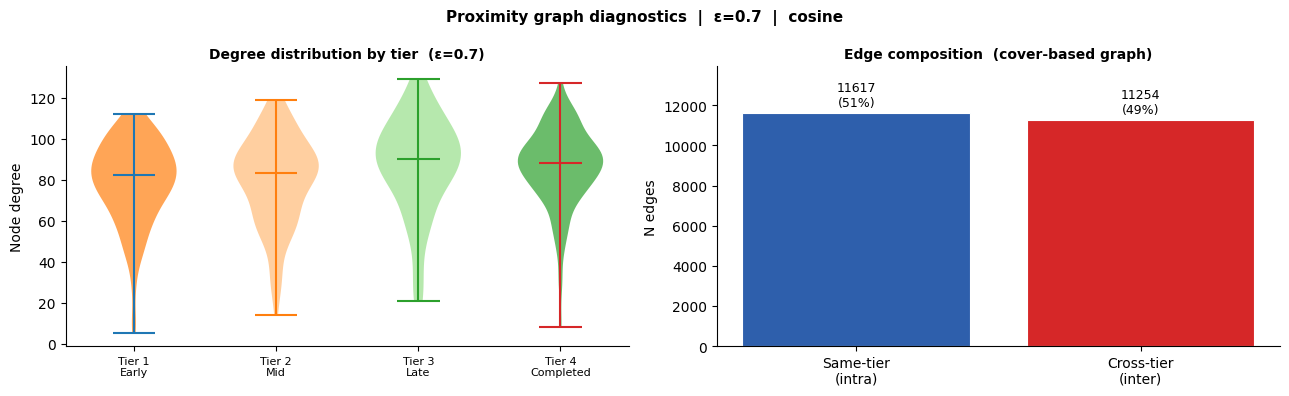

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Degree distribution by tier ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: degree distribution violin
degree_data = pd.DataFrame({
    'degree' : [G.degree(n) for n in G.nodes],
    'tier'   : [G.nodes[n]['tier'] for n in G.nodes],
    'label'  : [G.nodes[n]['tier_label'] for n in G.nodes],
})

active_tiers = sorted(degree_data['tier'].unique())
for i, tier in enumerate(active_tiers):
    vals = degree_data[degree_data['tier'] == tier]['degree']
    if len(vals) == 0:
        continue
    color = tier_colors.get(tier, '#aaaaaa')
    vp = axes[0].violinplot(vals, positions=[i], showmedians=True, widths=0.6)
    for part in vp['bodies']:
        part.set_facecolor(color)
        part.set_alpha(0.7)

axes[0].set_xticks(range(len(active_tiers)))
axes[0].set_xticklabels(
    [f"Tier {t}\n{tier_label_map[t].split()[0]}" for t in active_tiers],
    fontsize=8
)
axes[0].set_ylabel('Node degree', fontsize=10)
axes[0].set_title(f'Degree distribution by tier  (ε={EPSILON})',
                  fontsize=10, fontweight='bold')
sns.despine(ax=axes[0])

# Right: intra- vs inter-tier edge counts
intra = sum(1 for u, v in G.edges() if G.nodes[u]['tier'] == G.nodes[v]['tier'])
inter = sum(1 for u, v in G.edges() if G.nodes[u]['tier'] != G.nodes[v]['tier'])
axes[1].bar(['Same-tier\n(intra)', 'Cross-tier\n(inter)'],
            [intra, inter],
            color=['#2E5FAC', '#d62728'], edgecolor='white', linewidth=0.8)
axes[1].bar_label(axes[1].containers[0],
                  labels=[f'{intra}\n({intra/(intra+inter)*100:.0f}%)',
                           f'{inter}\n({inter/(intra+inter)*100:.0f}%)'],
                  fontsize=9, padding=3)
axes[1].set_ylabel('N edges', fontsize=10)
axes[1].set_title(f'Edge composition  (cover-based graph)',
                  fontsize=10, fontweight='bold')
axes[1].set_ylim(0, max(intra, inter) * 1.2)
sns.despine(ax=axes[1])

plt.suptitle(f'Proximity graph diagnostics  |  ε={EPSILON}  |  {METRIC}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('proximity_graph_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

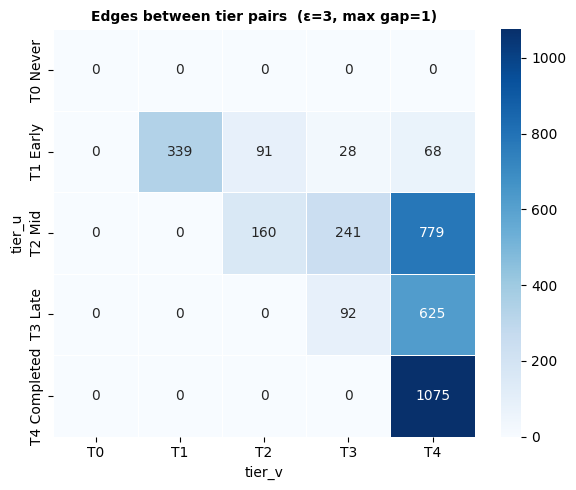


Summary:
  Total edges           : 3498
  Intra-tier edges      : 1666  (47.6%)
  Inter-tier edges      : 1832  (52.4%)
  Connected components  : 89
  Largest component     : 456 nodes
  Isolated nodes        : 79


In [55]:
# ── Cross-tier edge matrix ────────────────────────────────────────────────────
# How many edges connect each pair of tiers?
tier_pairs = pd.DataFrame(
    [(G.nodes[u]['tier'], G.nodes[v]['tier'])
     for u, v in G.edges()],
    columns=['tier_u', 'tier_v']
)
# Normalise so tier_u <= tier_v
tier_pairs[['tier_u','tier_v']] = np.sort(
    tier_pairs[['tier_u','tier_v']].values, axis=1
)
edge_matrix = pd.crosstab(tier_pairs['tier_u'], tier_pairs['tier_v'])

# Reindex to include all tiers
all_tiers = sorted(tier_label_map.keys())
edge_matrix = edge_matrix.reindex(index=all_tiers, columns=all_tiers, fill_value=0)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    edge_matrix,
    annot=True, fmt='d',
    cmap='Blues',
    linewidths=0.5,
    xticklabels=[f"T{t}" for t in all_tiers],
    yticklabels=[f"T{t} {tier_label_map[t].split()[0]}" for t in all_tiers],
    ax=ax,
)
ax.set_title(f'Edges between tier pairs  (ε={EPSILON}, max gap={MAX_TIER_GAP})',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('tier_edge_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSummary:")
print(f"  Total edges           : {G.number_of_edges()}")
print(f"  Intra-tier edges      : {intra}  ({intra/G.number_of_edges()*100:.1f}%)")
print(f"  Inter-tier edges      : {inter}  ({inter/G.number_of_edges()*100:.1f}%)")
print(f"  Connected components  : {nx.number_connected_components(G)}")
print(f"  Largest component     : "
      f"{max(len(c) for c in nx.connected_components(G))} nodes")
print(f"  Isolated nodes        : "
      f"{sum(1 for n in G.nodes if G.degree(n)==0)}")

## 8. Epsilon sensitivity analysis

How graph density and connectivity change with ε — helps you choose a principled value.

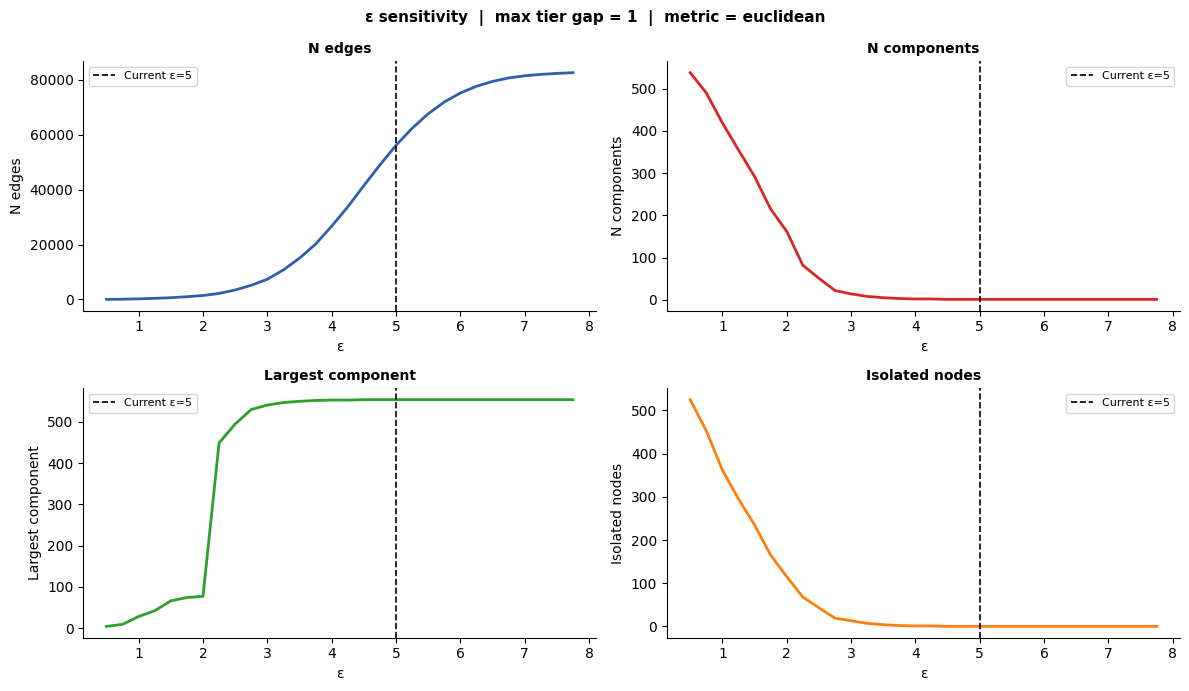


Selected ε stats:
 epsilon  n_edges  n_components  largest_comp  n_isolated  density_pct
     5.0    56174             1           554           0     36.67165


In [16]:
# ── Sweep ε and record graph statistics ───────────────────────────────────────
epsilon_range = np.arange(0.5, 8.0, 0.25)
sweep_records = []

for eps in epsilon_range:
    G_tmp = nx.Graph()
    G_tmp.add_nodes_from(range(len(df)))
    for i in range(len(df)):
        for j in range(i+1, len(df)):
            if D[i,j] <= eps:
                t_gap = abs(int(tiers[i]) - int(tiers[j])) \
                        if not (np.isnan(tiers[i]) or np.isnan(tiers[j])) else 99
                if t_gap <= MAX_TIER_GAP:
                    G_tmp.add_edge(i, j)
    comps = list(nx.connected_components(G_tmp))
    sweep_records.append({
        'epsilon'       : eps,
        'n_edges'       : G_tmp.number_of_edges(),
        'n_components'  : len(comps),
        'largest_comp'  : max(len(c) for c in comps) if comps else 0,
        'n_isolated'    : sum(1 for n in G_tmp.nodes if G_tmp.degree(n)==0),
        'density_pct'   : G_tmp.number_of_edges() / (len(df)*(len(df)-1)/2) * 100,
    })

sweep = pd.DataFrame(sweep_records)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()
metrics = [
    ('n_edges',      'N edges',           '#2E5FAC'),
    ('n_components', 'N components',      '#d62728'),
    ('largest_comp', 'Largest component', '#2ca02c'),
    ('n_isolated',   'Isolated nodes',    '#ff7f0e'),
]
for ax, (col, label, color) in zip(axes, metrics):
    ax.plot(sweep['epsilon'], sweep[col], color=color, linewidth=2)
    ax.axvline(EPSILON, color='black', linestyle='--',
               linewidth=1.2, label=f'Current ε={EPSILON}')
    ax.set_xlabel('ε', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle(f'ε sensitivity  |  max tier gap = {MAX_TIER_GAP}  |  metric = {METRIC}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('epsilon_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSelected ε stats:")
row = sweep[sweep['epsilon'].round(2) == round(EPSILON, 2)]
if not row.empty:
    print(row.to_string(index=False))

## 9. Parameter-grid batch run

Sweep over 60 combinations of metric, ε, lens function, and cover overlap.
Each graph is saved as a PNG in `w8/`; the final cell assembles them into a single grid image `w8/grid_all.png`.

| Axis | Values |
|---|---|
| **Lens** | `att_dens_w8`, `detox_los`, `density-knn (k=5)` |
| **Metric** | cosine (ε = 0.5–0.8) · mink p=2 (ε = 4.5–6.5) · mink p=4 (ε = 3.0–4.0) |
| **Overlap** | 0.5 · 0.7 |
| **n_bins** | 5 (uniform open cover) |

Node colour = retention tier. Layout = PCA (fixed, same for all graphs).

In [ ]:
# ── Batch Mapper graph: parameter grid ────────────────────────────────────────
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.lines import Line2D
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')

OUT_DIR   = 'w8'
N_BINS    = 5
DENSITY_K = 5
os.makedirs(OUT_DIR, exist_ok=True)

TIER_COLORS_DICT = {-1:'#aaaaaa', 1:'#ff7f0e', 2:'#ffbb78', 3:'#98df8a', 4:'#2ca02c'}
tiers_int = np.array([int(tiers[i]) if not np.isnan(tiers[i]) else -1
                      for i in range(len(df))])

# ── 1. Pre-compute distance matrices ─────────────────────────────────────────
print("Pre-computing distance matrices...")
dist_cache = {}
for metric, p in [('cosine', None), ('minkowski', 2), ('minkowski', 4)]:
    kw    = {'p': p} if p is not None else {}
    D_tmp = pairwise_distances(X, metric=metric, **kw)
    dist_cache[(metric, p)] = D_tmp
    nz = D_tmp[D_tmp > 0]
    print(f"  ({metric}, p={p}):  range [{nz.min():.3f}, {nz.max():.3f}]  "
          f"p25={np.percentile(nz, 25):.3f}  p50={np.percentile(nz, 50):.3f}  "
          f"p75={np.percentile(nz, 75):.3f}")

# ── 2. Filter functions ───────────────────────────────────────────────────────
print("\nPre-computing filter values...")
lens_cache = {}
lens_cache['feature:attendance_density_w8'] = df['attendance_density_w8'].values.astype(float)
lens_cache['feature:detox_los']             = df['detox_los'].values.astype(float)

knn_model          = NearestNeighbors(n_neighbors=DENSITY_K + 1, metric='euclidean')
knn_model.fit(X)
knn_dists, _       = knn_model.kneighbors(X)
lens_cache['density-knn'] = 1.0 / (knn_dists[:, 1:].mean(axis=1) + 1e-9)

for lk, v in lens_cache.items():
    print(f"  {lk}: [{np.nanmin(v):.4f}, {np.nanmax(v):.4f}]")

# ── 3. PCA layout — fixed across all graphs for visual comparability ──────────
pca_coords = PCA(n_components=2, random_state=42).fit_transform(X)
pos_fixed  = {i: (pca_coords[i, 0], pca_coords[i, 1]) for i in range(len(df))}

# ── 4. Helpers ────────────────────────────────────────────────────────────────
def build_uniform_cover(filt_vals, n_bins, overlap):
    """Uniform open cover: n_bins overlapping intervals spanning [min, max]."""
    fmin, fmax = np.nanmin(filt_vals), np.nanmax(filt_vals)
    rng = fmax - fmin
    # (n_bins-1)*step + width = rng,  step = width*(1-overlap)
    width = rng / ((n_bins - 1) * (1 - overlap) + 1)
    step  = width * (1 - overlap)
    return [(fmin + i * step, fmin + i * step + width + 1e-9) for i in range(n_bins)]

def membership_matrix(filt_vals, cover):
    """Boolean (n_patients × n_bins) membership matrix."""
    n, k = len(filt_vals), len(cover)
    M = np.zeros((n, k), dtype=np.int8)
    for j, (lo, hi) in enumerate(cover):
        valid   = ~np.isnan(filt_vals)
        M[:, j] = (valid & (filt_vals >= lo) & (filt_vals < hi)).astype(np.int8)
    return M

# ── 5. Parameter grid ─────────────────────────────────────────────────────────
LENS_KINDS = ['feature:attendance_density_w8', 'feature:detox_los', 'density-knn']
OVERLAPS   = [0.5, 0.7]
LENS_SHORT = {
    'feature:attendance_density_w8': 'att_dens_w8',
    'feature:detox_los':             'detox_los',
    'density-knn':                   f'dens_knn_k{DENSITY_K}',
}

PARAM_GRID = (
    [dict(metric='cosine',    p=None, epsilon=e, lens_kind=lk, overlap=ov)
     for e in [0.5, 0.6, 0.7, 0.8] for lk in LENS_KINDS for ov in OVERLAPS] +
    [dict(metric='minkowski', p=2,    epsilon=e, lens_kind=lk, overlap=ov)
     for e in [4.5, 5.5, 6.5]       for lk in LENS_KINDS for ov in OVERLAPS] +
    [dict(metric='minkowski', p=4,    epsilon=e, lens_kind=lk, overlap=ov)
     for e in [3.0, 3.5, 4.0]       for lk in LENS_KINDS for ov in OVERLAPS]
)
print(f"\nTotal combinations: {len(PARAM_GRID)}")

# ── 6. Generate individual graphs ─────────────────────────────────────────────
print(f"Generating {len(PARAM_GRID)} graphs (PCA layout) ...")

for idx, params in enumerate(PARAM_GRID):
    metric    = params['metric']
    p         = params['p']
    epsilon   = params['epsilon']
    lens_kind = params['lens_kind']
    overlap   = params['overlap']

    D_run = dist_cache[(metric, p)]
    filt  = lens_cache[lens_kind]
    cover = build_uniform_cover(filt, N_BINS, overlap)
    M     = membership_matrix(filt, cover)

    # Vectorised edge condition: within-ε AND shared cover set
    within = (D_run <= epsilon) & (D_run > 0)
    shared = (M @ M.T) > 0
    edges  = np.argwhere(np.triu(within & shared, k=1))

    G_run = nx.Graph()
    G_run.add_nodes_from(range(len(df)))
    if len(edges):
        G_run.add_edges_from(map(tuple, edges))

    n_e   = G_run.number_of_edges()
    n_c   = nx.number_connected_components(G_run)
    n_iso = sum(1 for n in G_run.nodes if G_run.degree(n) == 0)

    fig, ax = plt.subplots(figsize=(5, 4))
    nc = [TIER_COLORS_DICT.get(tiers_int[n], '#aaaaaa') for n in G_run.nodes]
    nx.draw_networkx_edges(G_run, pos_fixed, ax=ax,
                           alpha=0.10, width=0.3, edge_color='#888888')
    nx.draw_networkx_nodes(G_run, pos_fixed, ax=ax,
                           node_color=nc, node_size=8, alpha=0.85)

    m_str = 'cosine' if metric == 'cosine' else f'mink(p={p})'
    ax.set_title(
        f"lens={LENS_SHORT[lens_kind]}   {m_str}   ε={epsilon}   overlap={overlap}\n"
        f"E={n_e:,}   C={n_c}   iso={n_iso}",
        fontsize=7, pad=3,
    )
    ax.axis('off')
    legend_h = [Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=TIER_COLORS_DICT[t], markersize=5, label=f'T{t}')
                for t in [1, 2, 3, 4]]
    ax.legend(handles=legend_h, fontsize=5, loc='lower right',
              framealpha=0.7, ncol=2, borderpad=0.3)
    plt.tight_layout(pad=0.4)

    mf    = 'cos' if metric == 'cosine' else f'mink_p{p}'
    fname = f"{idx:03d}_{LENS_SHORT[lens_kind]}_{mf}_eps{epsilon}_ov{overlap}.png"
    params['_path'] = os.path.join(OUT_DIR, fname)
    plt.savefig(params['_path'], dpi=100, bbox_inches='tight')
    plt.close()

    if (idx + 1) % 10 == 0:
        print(f"  {idx + 1}/{len(PARAM_GRID)}")

print(f"\nAll {len(PARAM_GRID)} individual graphs saved to '{OUT_DIR}/'")
print("Run the next cell to assemble the grid image.")

In [ ]:
# ── Assemble parameter-grid image ─────────────────────────────────────────────
# Rows  = metric × p × epsilon  (10: 4 cosine + 3 mink-p2 + 3 mink-p4)
# Cols  = lens_kind × overlap   (3 × 2 = 6)

row_combos = (
    [('cosine',    None, e) for e in [0.5, 0.6, 0.7, 0.8]] +
    [('minkowski', 2,    e) for e in [4.5, 5.5, 6.5]]      +
    [('minkowski', 4,    e) for e in [3.0, 3.5, 4.0]]
)
col_combos = [(lk, ov) for lk in LENS_KINDS for ov in OVERLAPS]

n_rows, n_cols = len(row_combos), len(col_combos)

img_lookup = {
    (m['metric'], m['p'], m['epsilon'], m['lens_kind'], m['overlap']): m['_path']
    for m in PARAM_GRID
}

fig_g, axes_g = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 3.2, n_rows * 2.6),
    gridspec_kw=dict(hspace=0.04, wspace=0.04),
)

for ri, (metric, p, eps) in enumerate(row_combos):
    for ci, (lk, ov) in enumerate(col_combos):
        ax   = axes_g[ri, ci]
        path = img_lookup.get((metric, p, eps, lk, ov))
        if path and os.path.isfile(path):
            ax.imshow(mpimg.imread(path))
        else:
            ax.text(0.5, 0.5, '—', ha='center', va='center',
                    transform=ax.transAxes, fontsize=14, color='#999')
        ax.set_xticks([])
        ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_linewidth(0.3)

        if ci == 0:
            m_lbl = 'cosine' if metric == 'cosine' else f'mink p={p}'
            ax.set_ylabel(f"{m_lbl}\nε={eps}", fontsize=6.5, rotation=0,
                          labelpad=52, va='center')

for ci, (lk, ov) in enumerate(col_combos):
    axes_g[0, ci].set_title(f"{LENS_SHORT[lk]}\noverlap={ov}", fontsize=7, pad=4)

plt.suptitle(
    f"Mapper proximity graphs — parameter grid\n"
    f"n_bins={N_BINS}  |  n={len(df)} patients  |  node colour = retention tier",
    fontsize=9, fontweight='bold', y=1.005,
)

grid_path = os.path.join(OUT_DIR, 'grid_all.png')
plt.savefig(grid_path, dpi=120, bbox_inches='tight')
plt.close()
print(f"Grid saved  →  '{grid_path}'  ({n_rows} rows × {n_cols} cols = {n_rows * n_cols} panels)")